# Online Retail Customer Segmentation — RFM + Clustering

**Objective:** Perform end-to-end RFM analysis and cluster customers using K-Means, Hierarchical Clustering, and DBSCAN.  
**Dataset:** [Online Retail Dataset — Kaggle](https://www.kaggle.com/datasets/lakshmi25npathi/online-retail-dataset)  
**Pipeline:**
1. Data Preprocessing
2. RFM Feature Engineering
3. Data Scaling
4. Clustering (K-Means · Hierarchical · DBSCAN)
5. Dimensionality Reduction & Visualization (PCA · t-SNE)
6. Evaluation & Summary

---
##  Step 0 — Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import skew

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

---
##  Step 1 — Load & Explore the Dataset

In [9]:
# ── Upload the CSV from Kaggle to Colab first, then run this cell ──
# from google.colab import files
# uploaded = files.upload()   # select 'Online Retail.xlsx' or 'online_retail.csv'

# If you have the Excel version:
# df = pd.read_excel("Online Retail.xlsx", dtype={"CustomerID": str})

# If you have the CSV version:
df = pd.read_excel("./online_retail_II.xlsx", engine="openpyxl", dtype={"CustomerID": str})

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [10]:
print(df.shape)
print(df.info())
print(df.describe())

(525461, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB
None
            Quantity                    InvoiceDate          Price  \
count  525461.000000                         525461  525461.000000   
mean       10.337667  2010-06-28 11:37:36.845017856       4.688834   
min     -9600.000000            2009-12-01 07:45:00  -53594.360000   
25%        

In [11]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64


---
##  Step 2 — Data Preprocessing

In [13]:
# Drop rows where CustomerID is missing — we cannot build RFM without it
df.dropna(subset=["Customer ID"], inplace=True)

print(f"Rows after dropping missing CustomerID: {df.shape[0]}")

Rows after dropping missing CustomerID: 417534


In [18]:
# Remove rows with negative or zero Quantity (returns / cancellations)
df = df[df["Quantity"] > 0]

# Remove rows with negative or zero UnitPrice (data errors)
df = df[df["Price"] > 0]

print(f"Rows after removing negatives: {df.shape[0]}")

Rows after removing negatives: 407664


In [19]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

print(f"Rows after removing duplicates: {df.shape[0]}")

Rows after removing duplicates: 400916


In [21]:
# Parse InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Create a TotalPrice column (Quantity × UnitPrice)
df["TotalPrice"] = df["Quantity"] * df["Price"]

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


---
##  Step 3 — RFM Feature Engineering

| Feature | Definition |
|---------|------------|
| **Recency** | Days since the customer's last purchase (lower = more recent) |
| **Frequency** | Number of unique invoices per customer |
| **Monetary** | Total spend (sum of Quantity × UnitPrice) |

In [24]:
# Snapshot date = 1 day after the latest transaction in the dataset
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {snapshot_date}")

rfm = df.groupby("Customer ID").agg(
    Recency   = ("InvoiceDate",  lambda x: (snapshot_date - x.max()).days),
    Frequency = ("Invoice",    "nunique"),
    Monetary  = ("TotalPrice",   "sum")
).reset_index()

rfm.head(10)

Snapshot date: 2010-12-10 20:01:00


,Customer ID,Recency,Frequency,Monetary
0,12346.0,165,11,372.86
1,12347.0,3,2,1323.32
2,12348.0,74,1,222.16
3,12349.0,43,3,2671.14
4,12351.0,11,1,300.93
5,12352.0,11,2,343.80
6,12353.0,44,1,317.76
7,12355.0,203,1,488.21
8,12356.0,16,3,3560.30
9,12357.0,24,2,12079.99


In [25]:
print(rfm.describe())

        Customer ID      Recency    Frequency       Monetary
count   4312.000000  4312.000000  4312.000000    4312.000000
mean   15349.290353    91.171846     4.455705    2040.406712
std     1701.200176    96.860633     8.170213    8911.755977
min    12346.000000     1.000000     1.000000       2.950000
25%    13882.500000    18.000000     1.000000     307.187500
50%    15350.500000    53.000000     2.000000     701.615000
75%    16834.250000   136.000000     5.000000    1714.932500
max    18287.000000   374.000000   205.000000  349164.350000


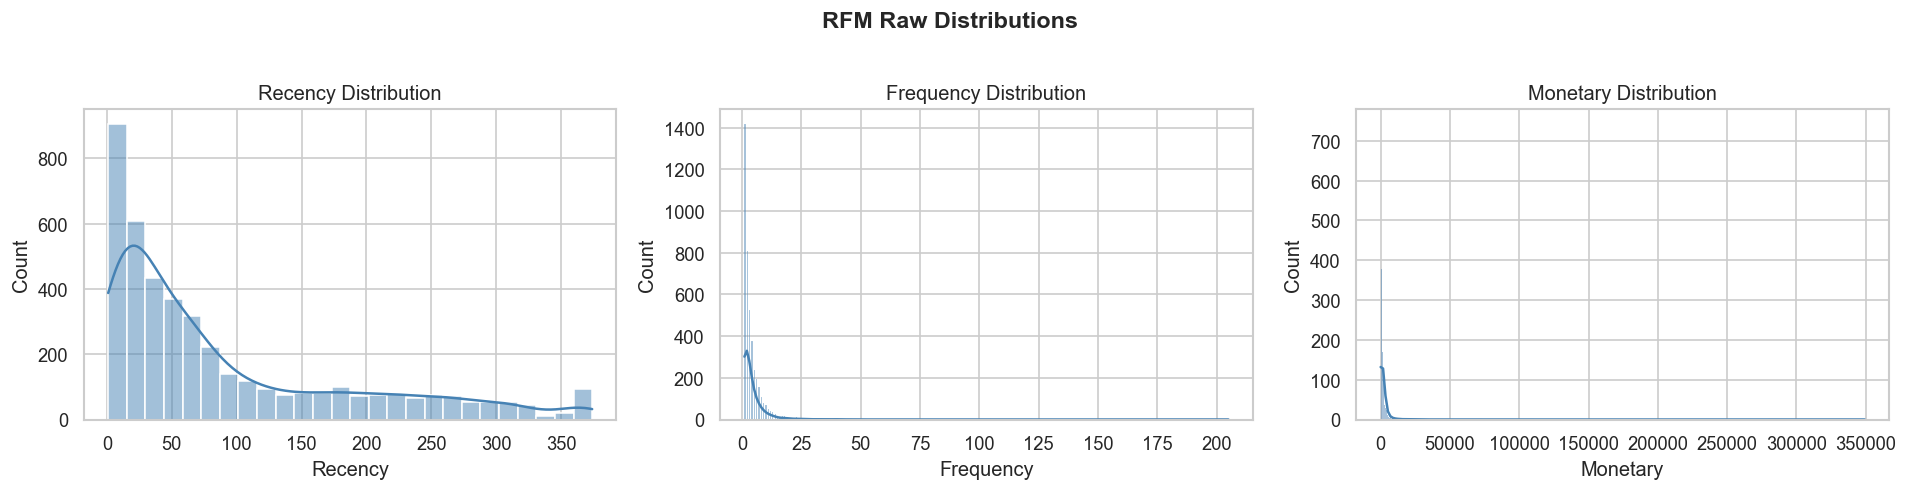

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, ["Recency", "Frequency", "Monetary"]):
    sns.histplot(rfm[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(f"{col} Distribution")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.suptitle("RFM Raw Distributions", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
##  Step 4 — Data Scaling

RFM features are typically right-skewed.  
- If skewness > 1 → apply **log transform** then **StandardScaler**  
- Otherwise → apply **StandardScaler** directly

In [27]:
for col in ["Recency", "Frequency", "Monetary"]:
    s = skew(rfm[col])
    print(f"{col} skewness: {s:.3f}")

Recency skewness: 1.282
Frequency skewness: 10.543
Monetary skewness: 23.992


In [28]:
rfm_log = rfm[["Recency", "Frequency", "Monetary"]].copy()

# Log-transform skewed features (add 1 to avoid log(0))
for col in ["Recency", "Frequency", "Monetary"]:
    if abs(skew(rfm_log[col])) > 1:
        rfm_log[col] = np.log1p(rfm_log[col])

# Apply StandardScaler
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=["Recency", "Frequency", "Monetary"])

print("Scaled RFM — first 5 rows:")
print(rfm_scaled_df.head())

Scaled RFM — first 5 rows:
    Recency  Frequency  Monetary
0  0.966262   1.613017 -0.534787
1 -1.900165  -0.394693  0.452542
2  0.355000  -0.981910 -0.937590
3 -0.055302   0.021945  1.000535
4 -1.054928  -0.981910 -0.701598


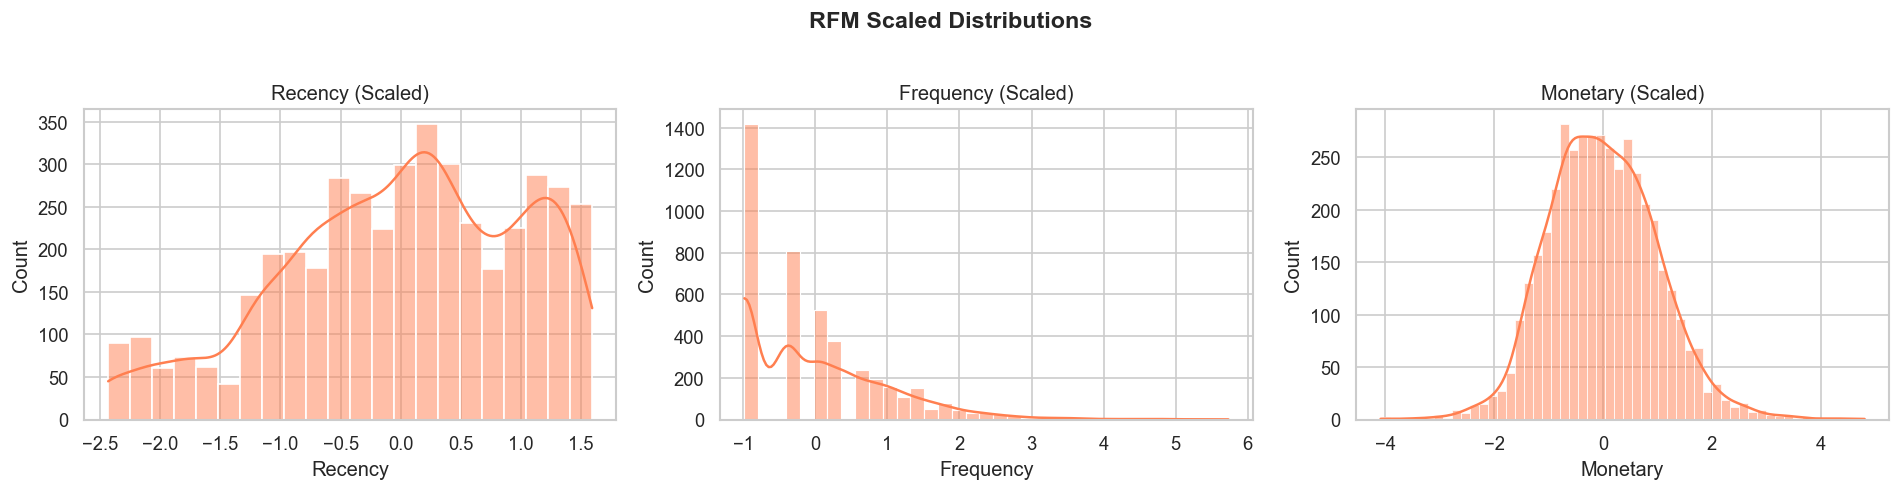

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, ["Recency", "Frequency", "Monetary"]):
    sns.histplot(rfm_scaled_df[col], kde=True, ax=ax, color="coral")
    ax.set_title(f"{col} (Scaled)")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.suptitle("RFM Scaled Distributions", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
##  Step 5 — K-Means Clustering

### 5a. Elbow Method — Finding Optimal K

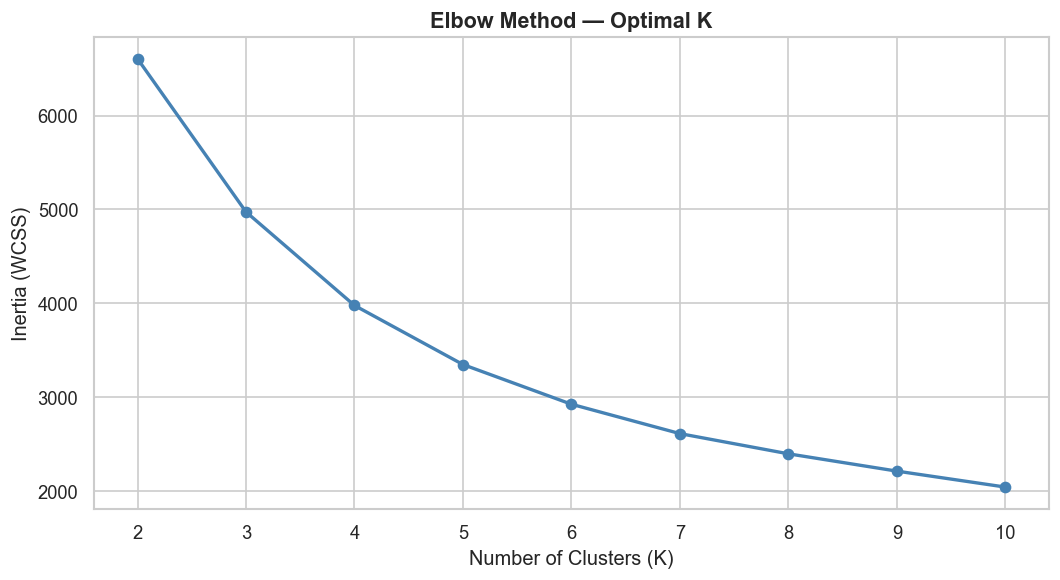

In [30]:
inertia_values = []  # within-cluster sum of squares (WCSS)
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia_values.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(k_range, inertia_values, marker="o", color="steelblue", linewidth=2)
plt.title("Elbow Method — Optimal K", fontsize=13, fontweight="bold")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (WCSS)")
plt.xticks(k_range)
plt.tight_layout()
plt.show()

### 5b. Silhouette Score — Confirming Optimal K

K=2  Silhouette Score: 0.4223
K=3  Silhouette Score: 0.3284
K=4  Silhouette Score: 0.3314
K=5  Silhouette Score: 0.3192
K=6  Silhouette Score: 0.3119
K=7  Silhouette Score: 0.3075
K=8  Silhouette Score: 0.2789
K=9  Silhouette Score: 0.2762
K=10  Silhouette Score: 0.2795


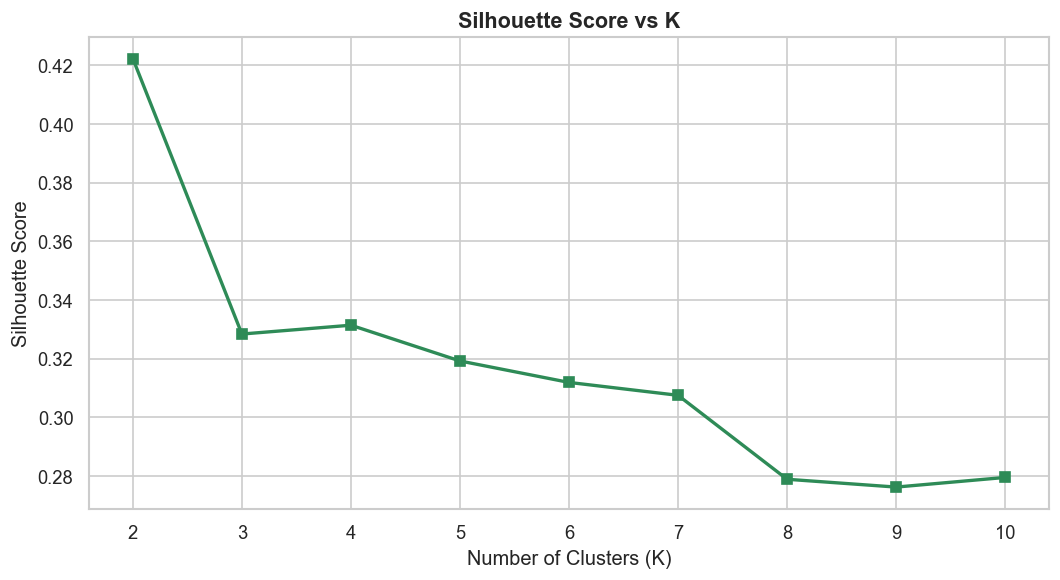

In [31]:
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)
    print(f"K={k}  Silhouette Score: {score:.4f}")

plt.figure(figsize=(9, 5))
plt.plot(k_range, silhouette_scores, marker="s", color="seagreen", linewidth=2)
plt.title("Silhouette Score vs K", fontsize=13, fontweight="bold")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(k_range)
plt.tight_layout()
plt.show()

### 5c. Fit Final K-Means Model

In [32]:
# Choose optimal K based on elbow + silhouette (typically 3–5 for retail RFM)
OPTIMAL_K = 4

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)

rfm["KMeans_Cluster"] = kmeans.fit_predict(rfm_scaled)

print("K-Means cluster counts:")
print(rfm["KMeans_Cluster"].value_counts())

K-Means cluster counts:
KMeans_Cluster
2    1378
3    1211
0     945
1     778
Name: count, dtype: int64


In [33]:
# Cluster profiles — mean RFM per cluster
kmeans_profile = rfm.groupby("KMeans_Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(2)

print("K-Means Cluster Profiles:")
print(kmeans_profile)

K-Means Cluster Profiles:
                Recency  Frequency  Monetary
KMeans_Cluster                              
0                 23.95       1.97    532.08
1                 13.83      13.56   7381.58
2                190.57       1.30    305.66
3                 80.21       4.14   1759.99


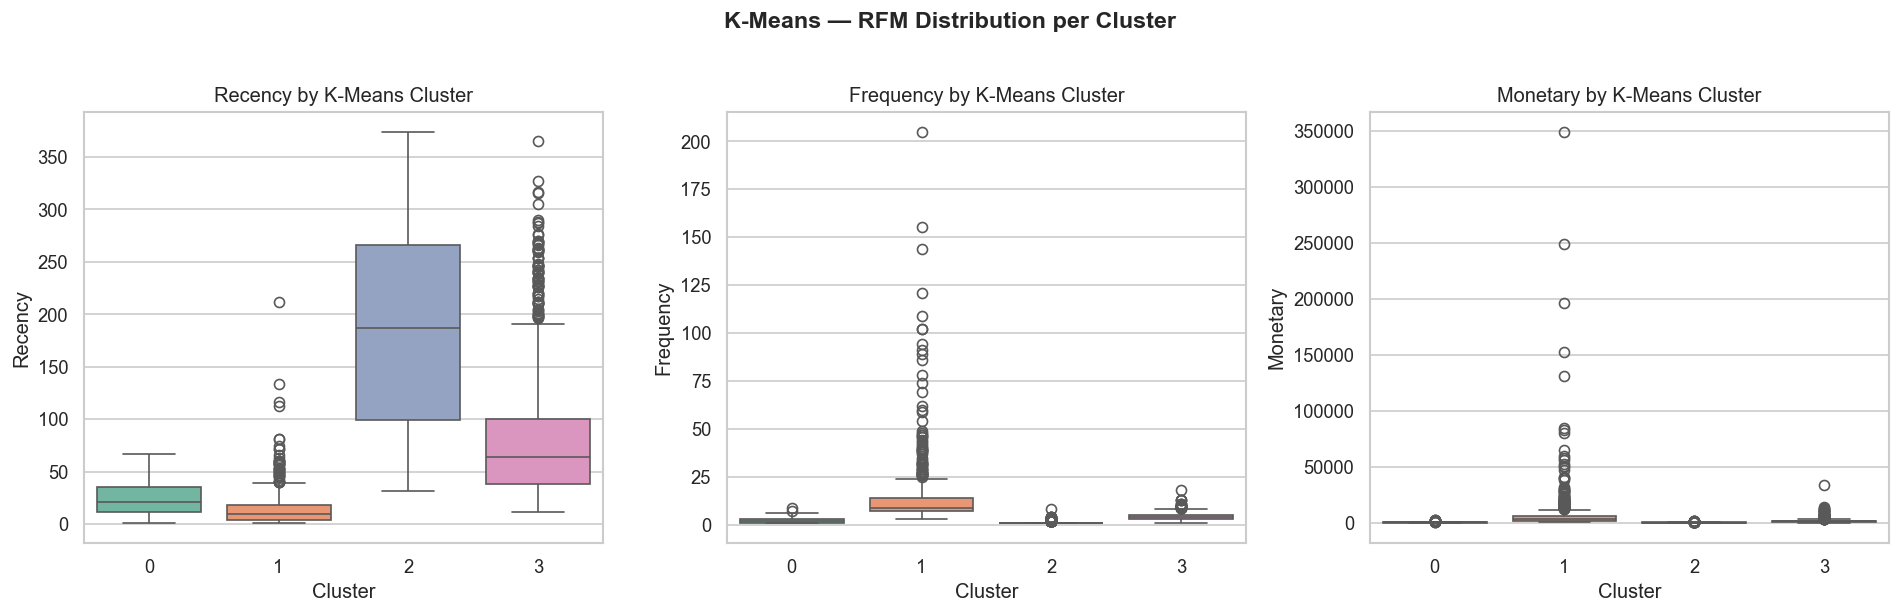

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ["Recency", "Frequency", "Monetary"]):
    sns.boxplot(x="KMeans_Cluster", y=col, data=rfm, ax=ax, palette="Set2")
    ax.set_title(f"{col} by K-Means Cluster")
    ax.set_xlabel("Cluster")
    ax.set_ylabel(col)

plt.suptitle("K-Means — RFM Distribution per Cluster", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
##  Step 6 — Hierarchical Clustering

### 6a. Dendrogram

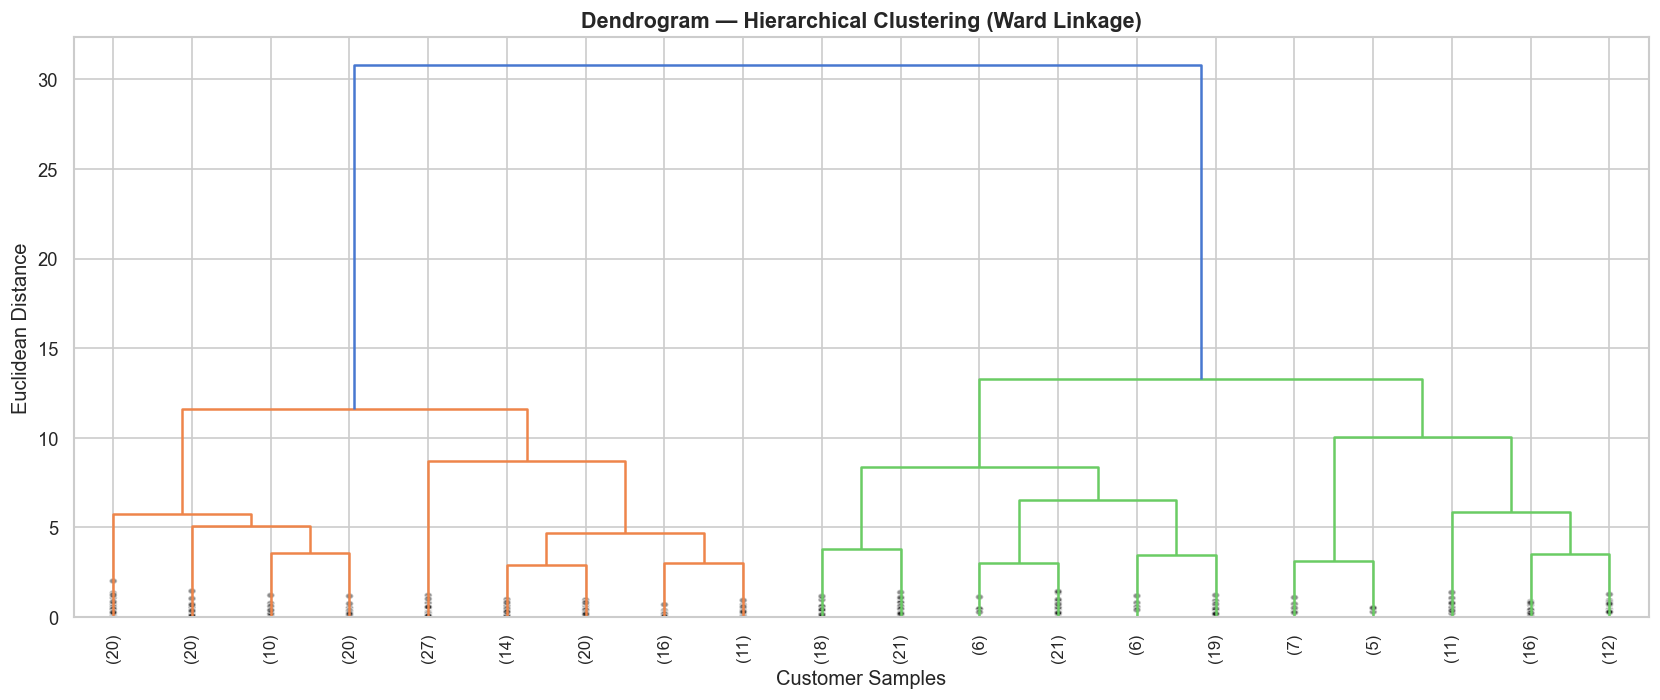

In [35]:
# Use a sample for the dendrogram (full dataset is too large to plot)
sample_idx = np.random.choice(len(rfm_scaled), size=300, replace=False)
rfm_sample = rfm_scaled[sample_idx]

linked = linkage(rfm_sample, method="ward")  # Ward minimizes within-cluster variance

plt.figure(figsize=(14, 6))
dendrogram(
    linked,
    truncate_mode="lastp",    # show only the last p merged clusters
    p=20,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True,
    color_threshold=0.7 * max(linked[:, 2])
)
plt.title("Dendrogram — Hierarchical Clustering (Ward Linkage)", fontsize=13, fontweight="bold")
plt.xlabel("Customer Samples")
plt.ylabel("Euclidean Distance")
plt.tight_layout()
plt.show()

### 6b. Fit Agglomerative Clustering

In [36]:
agg = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage="ward")

rfm["Hierarchical_Cluster"] = agg.fit_predict(rfm_scaled)

print("Hierarchical cluster counts:")
print(rfm["Hierarchical_Cluster"].value_counts())

Hierarchical cluster counts:
Hierarchical_Cluster
0    1631
1    1079
3     995
2     607
Name: count, dtype: int64


In [37]:
# Cluster profiles
hier_profile = rfm.groupby("Hierarchical_Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(2)

print("Hierarchical Cluster Profiles:")
print(hier_profile)

Hierarchical Cluster Profiles:
                      Recency  Frequency  Monetary
Hierarchical_Cluster                              
0                       66.71       4.24   1765.81
1                      218.43       1.29    272.43
2                       12.49      15.44   8592.58
3                       41.26       1.54    410.60


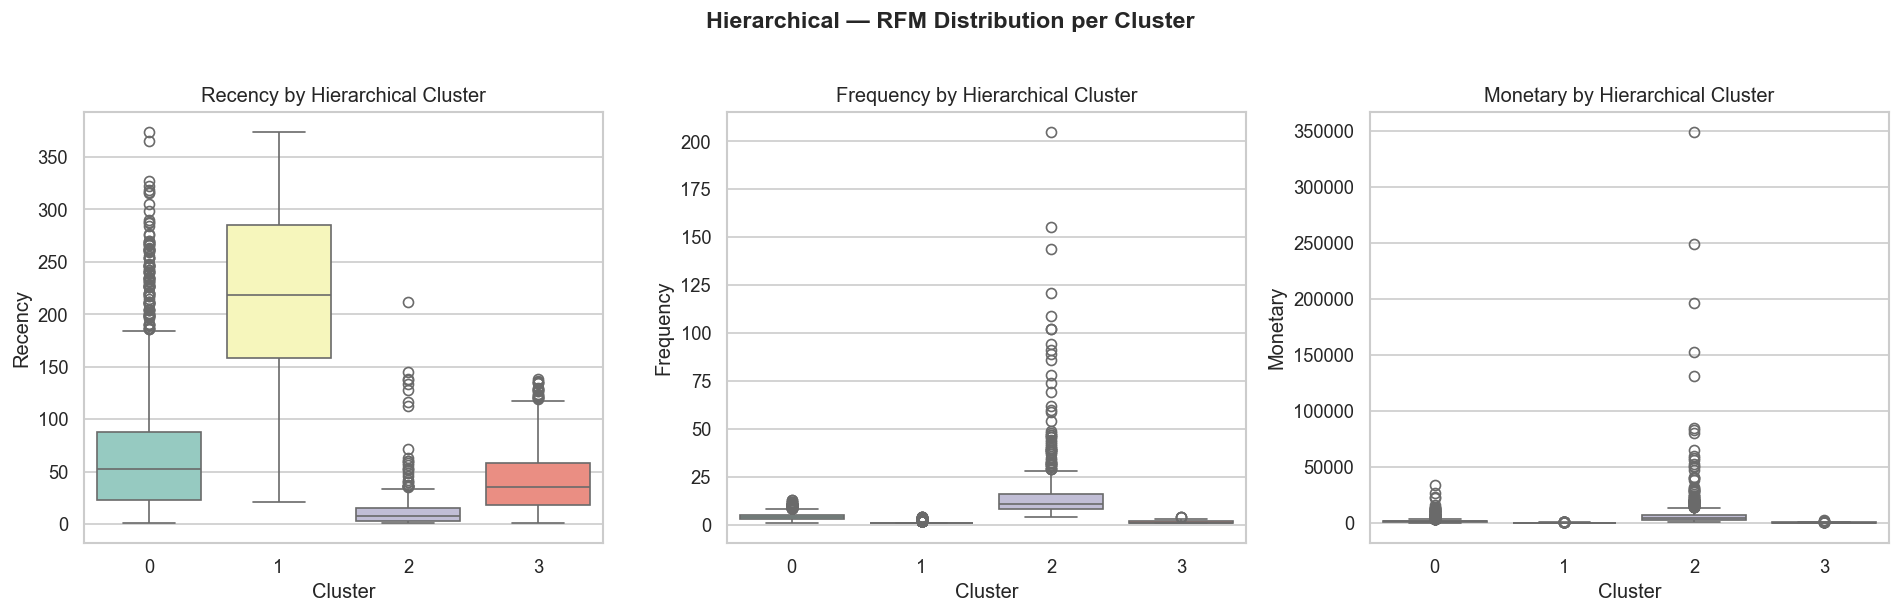

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ["Recency", "Frequency", "Monetary"]):
    sns.boxplot(x="Hierarchical_Cluster", y=col, data=rfm, ax=ax, palette="Set3")
    ax.set_title(f"{col} by Hierarchical Cluster")
    ax.set_xlabel("Cluster")
    ax.set_ylabel(col)

plt.suptitle("Hierarchical — RFM Distribution per Cluster", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
##  Step 7 — DBSCAN Clustering (Density-Based)

> DBSCAN identifies **core points**, **border points**, and **noise/outliers** (label = -1).  
> No need to pre-specify the number of clusters.

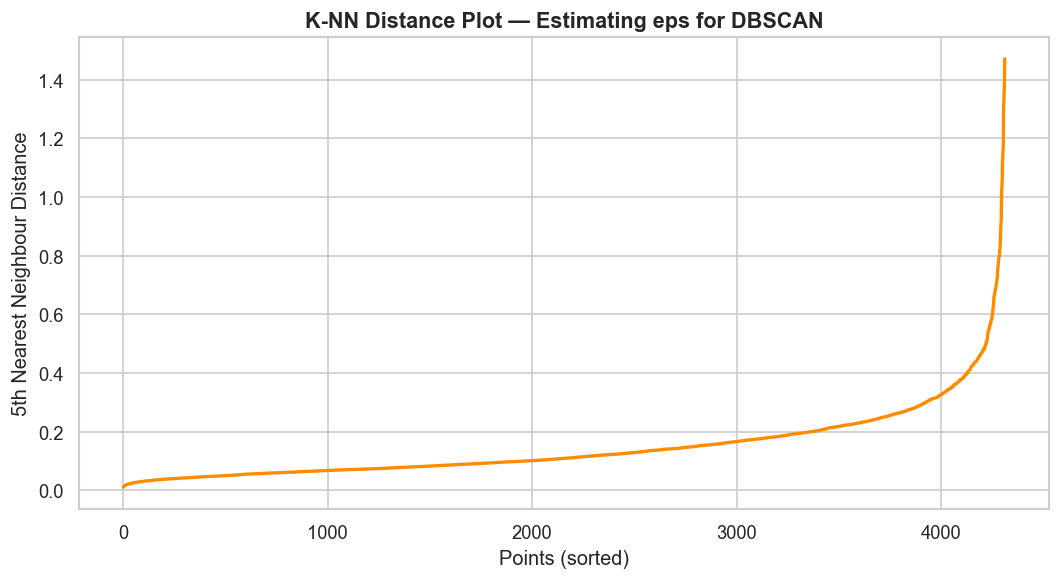

Tip: Look for the 'elbow' in the curve above — that is your eps value.


In [40]:
# Use k-nearest-neighbour distances to estimate a good eps value
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=5)
nn.fit(rfm_scaled)

distances, _ = nn.kneighbors(rfm_scaled)

distances_sorted = np.sort(distances[:, 4])  # 5th nearest neighbour distance

plt.figure(figsize=(9, 5))
plt.plot(distances_sorted, color="darkorange", linewidth=2)
plt.title("K-NN Distance Plot — Estimating eps for DBSCAN", fontsize=13, fontweight="bold")
plt.xlabel("Points (sorted)")
plt.ylabel("5th Nearest Neighbour Distance")
plt.tight_layout()
plt.show()

print("Tip: Look for the 'elbow' in the curve above — that is your eps value.")

In [41]:
# Fit DBSCAN — adjust eps based on the plot above
dbscan = DBSCAN(eps=0.5, min_samples=5)

rfm["DBSCAN_Cluster"] = dbscan.fit_predict(rfm_scaled)

n_clusters_db = len(set(rfm["DBSCAN_Cluster"])) - (1 if -1 in rfm["DBSCAN_Cluster"].values else 0)
n_noise       = (rfm["DBSCAN_Cluster"] == -1).sum()

print(f"DBSCAN Clusters Found: {n_clusters_db}")
print(f"Noise Points (outliers): {n_noise}")
print(rfm["DBSCAN_Cluster"].value_counts())

DBSCAN Clusters Found: 2
Noise Points (outliers): 52
DBSCAN_Cluster
 0    2847
 1    1413
-1      52
Name: count, dtype: int64


---
##  Step 8 — PCA: Dimensionality Reduction to 2D

In [42]:
pca = PCA(n_components=2, random_state=42)

pca_components = pca.fit_transform(rfm_scaled)

rfm["PCA_1"] = pca_components[:, 0]
rfm["PCA_2"] = pca_components[:, 1]

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.3f}")

Explained variance ratio: [0.74229501 0.19870302]
Total variance explained: 0.941


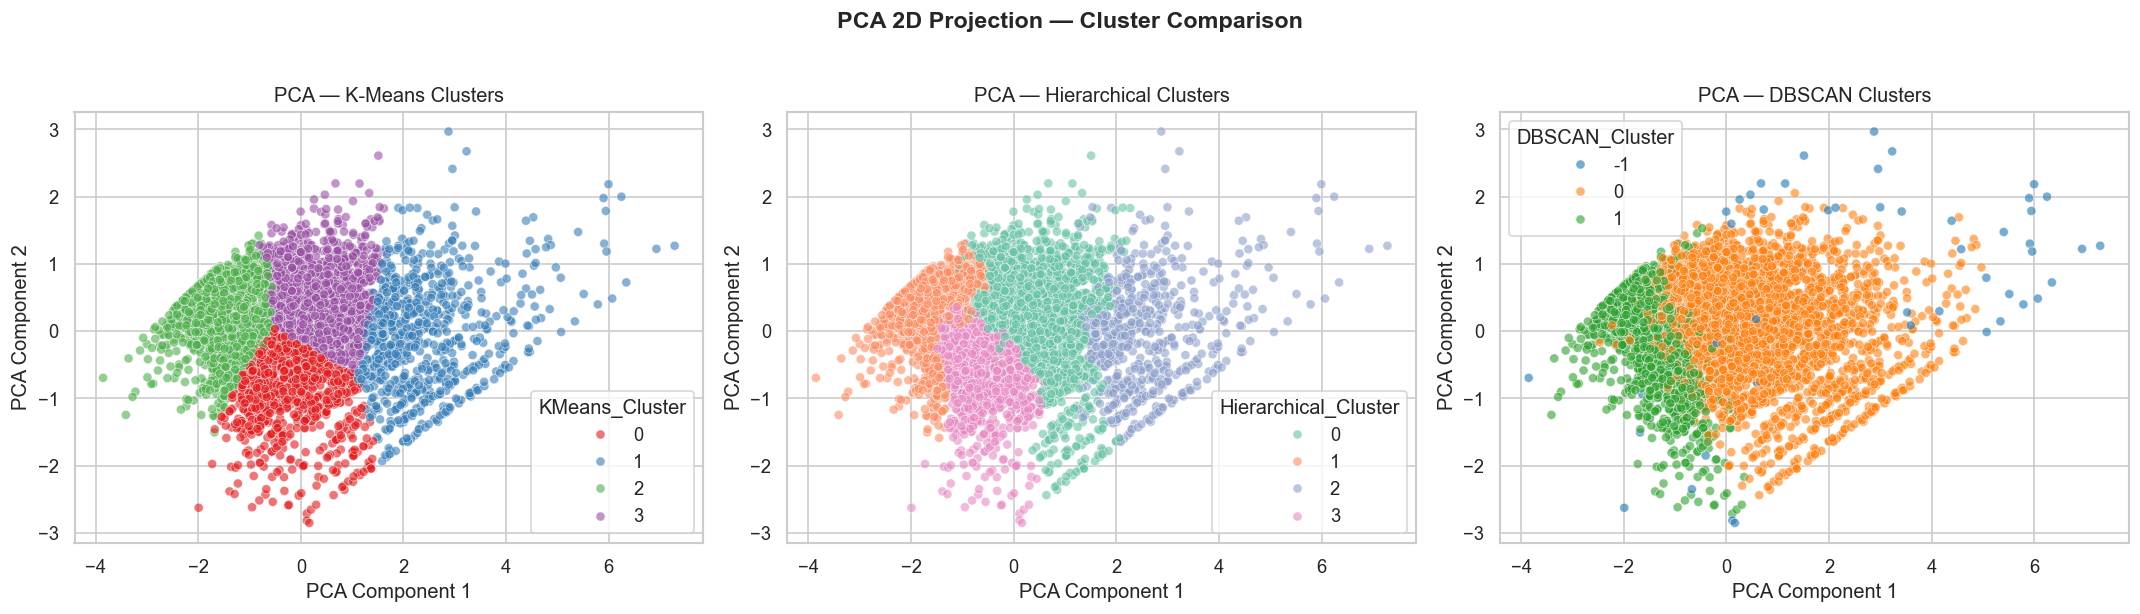

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cluster_cols = ["KMeans_Cluster", "Hierarchical_Cluster", "DBSCAN_Cluster"]
titles       = ["K-Means", "Hierarchical", "DBSCAN"]
palettes     = ["Set1", "Set2", "tab10"]

for ax, col, title, pal in zip(axes, cluster_cols, titles, palettes):
    sns.scatterplot(
        x="PCA_1", y="PCA_2",
        hue=col,
        data=rfm,
        palette=pal,
        ax=ax,
        alpha=0.6,
        s=30,
        legend="full"
    )
    ax.set_title(f"PCA — {title} Clusters")
    ax.set_xlabel("PCA Component 1")
    ax.set_ylabel("PCA Component 2")

plt.suptitle("PCA 2D Projection — Cluster Comparison", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
##  Step 9 — t-SNE: Non-Linear Visualization

In [44]:
# t-SNE is computationally expensive — subsample if dataset is large
MAX_TSNE_SAMPLES = 3000

if len(rfm_scaled) > MAX_TSNE_SAMPLES:
    tsne_idx = np.random.choice(len(rfm_scaled), size=MAX_TSNE_SAMPLES, replace=False)
else:
    tsne_idx = np.arange(len(rfm_scaled))

tsne = TSNE(n_components=2, perplexity=40, random_state=42, n_iter=1000)

tsne_components = tsne.fit_transform(rfm_scaled[tsne_idx])

rfm_tsne = rfm.iloc[tsne_idx].copy()
rfm_tsne["TSNE_1"] = tsne_components[:, 0]
rfm_tsne["TSNE_2"] = tsne_components[:, 1]

print(f"t-SNE fitted on {len(tsne_idx)} samples.")

t-SNE fitted on 3000 samples.


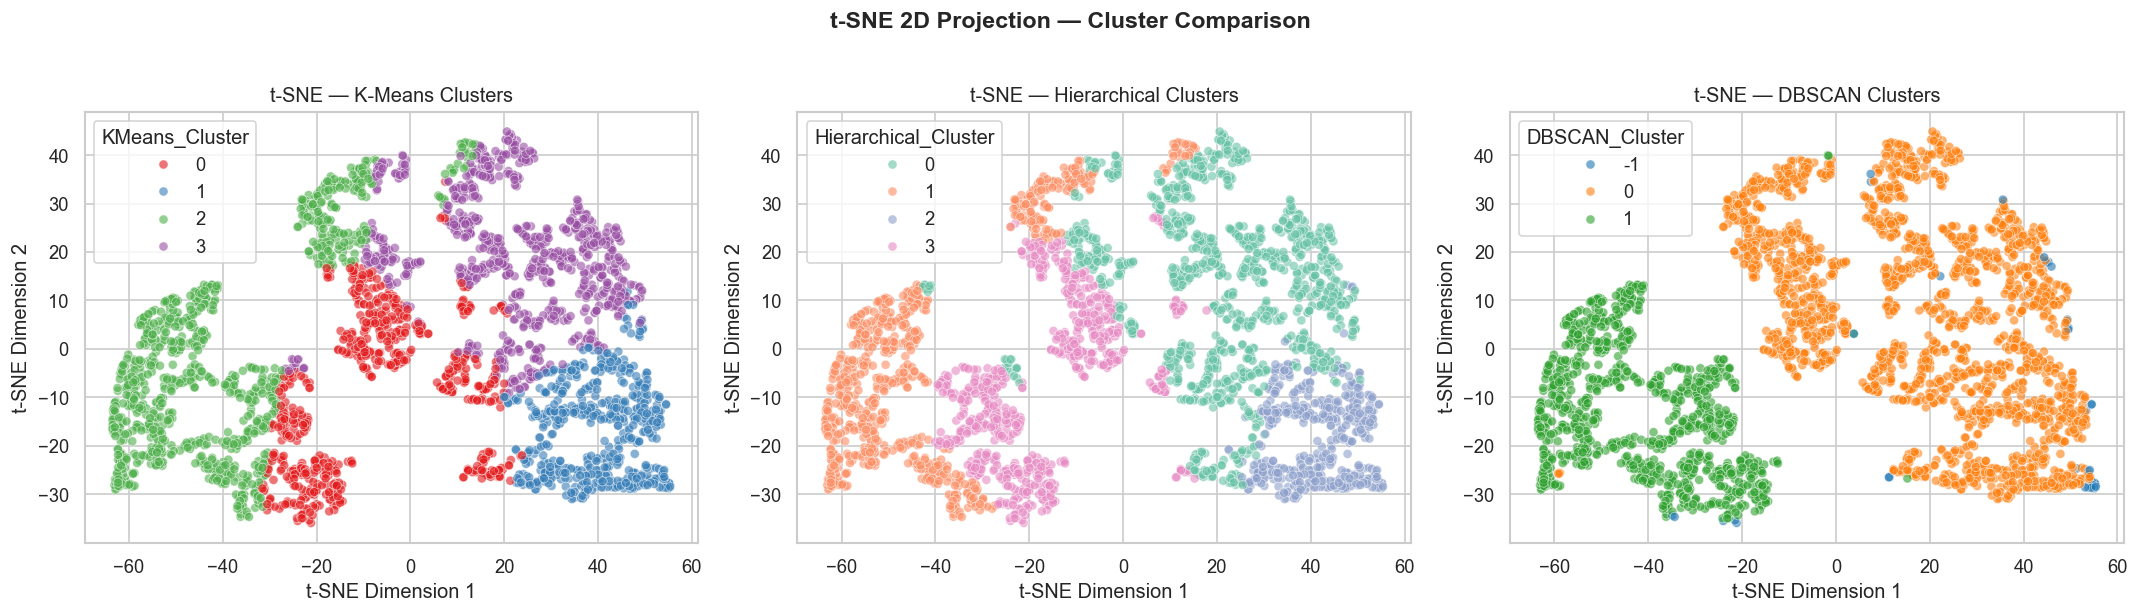

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, title, pal in zip(axes, cluster_cols, titles, palettes):
    sns.scatterplot(
        x="TSNE_1", y="TSNE_2",
        hue=col,
        data=rfm_tsne,
        palette=pal,
        ax=ax,
        alpha=0.6,
        s=30,
        legend="full"
    )
    ax.set_title(f"t-SNE — {title} Clusters")
    ax.set_xlabel("t-SNE Dimension 1")
    ax.set_ylabel("t-SNE Dimension 2")

plt.suptitle("t-SNE 2D Projection — Cluster Comparison", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 📋 Step 10 — Evaluation & Summary Table

In [46]:
# Silhouette scores for K-Means and Hierarchical (DBSCAN may have noise label -1)
sil_kmeans = silhouette_score(rfm_scaled, rfm["KMeans_Cluster"])
sil_hier   = silhouette_score(rfm_scaled, rfm["Hierarchical_Cluster"])

# For DBSCAN: exclude noise points (label == -1) from silhouette
db_mask     = rfm["DBSCAN_Cluster"] != -1
sil_dbscan  = silhouette_score(rfm_scaled[db_mask], rfm.loc[db_mask, "DBSCAN_Cluster"]) if db_mask.sum() > 1 else float("nan")

print(f"K-Means    Silhouette Score : {sil_kmeans:.4f}")
print(f"Hierarchical Silhouette Score: {sil_hier:.4f}")
print(f"DBSCAN     Silhouette Score : {sil_dbscan:.4f}")

K-Means    Silhouette Score : 0.3314
Hierarchical Silhouette Score: 0.2778
DBSCAN     Silhouette Score : 0.2945


In [47]:
summary = pd.DataFrame({
    "Algorithm"        : ["K-Means", "Hierarchical (Ward)", "DBSCAN"],
    "Num Clusters"     : [
        rfm["KMeans_Cluster"].nunique(),
        rfm["Hierarchical_Cluster"].nunique(),
        n_clusters_db
    ],
    "Noise Points"     : [0, 0, int(n_noise)],
    "Silhouette Score" : [round(sil_kmeans, 4), round(sil_hier, 4), round(sil_dbscan, 4)],
    "Requires K?"      : ["Yes", "Yes", "No"],
    "Handles Outliers?": ["No", "No", "Yes"]
})

print("\n===== Clustering Algorithm Comparison =====")
print(summary.to_string(index=False))


===== Clustering Algorithm Comparison =====
          Algorithm  Num Clusters  Noise Points  Silhouette Score Requires K? Handles Outliers?
            K-Means             4             0            0.3314         Yes                No
Hierarchical (Ward)             4             0            0.2778         Yes                No
             DBSCAN             2            52            0.2945          No               Yes


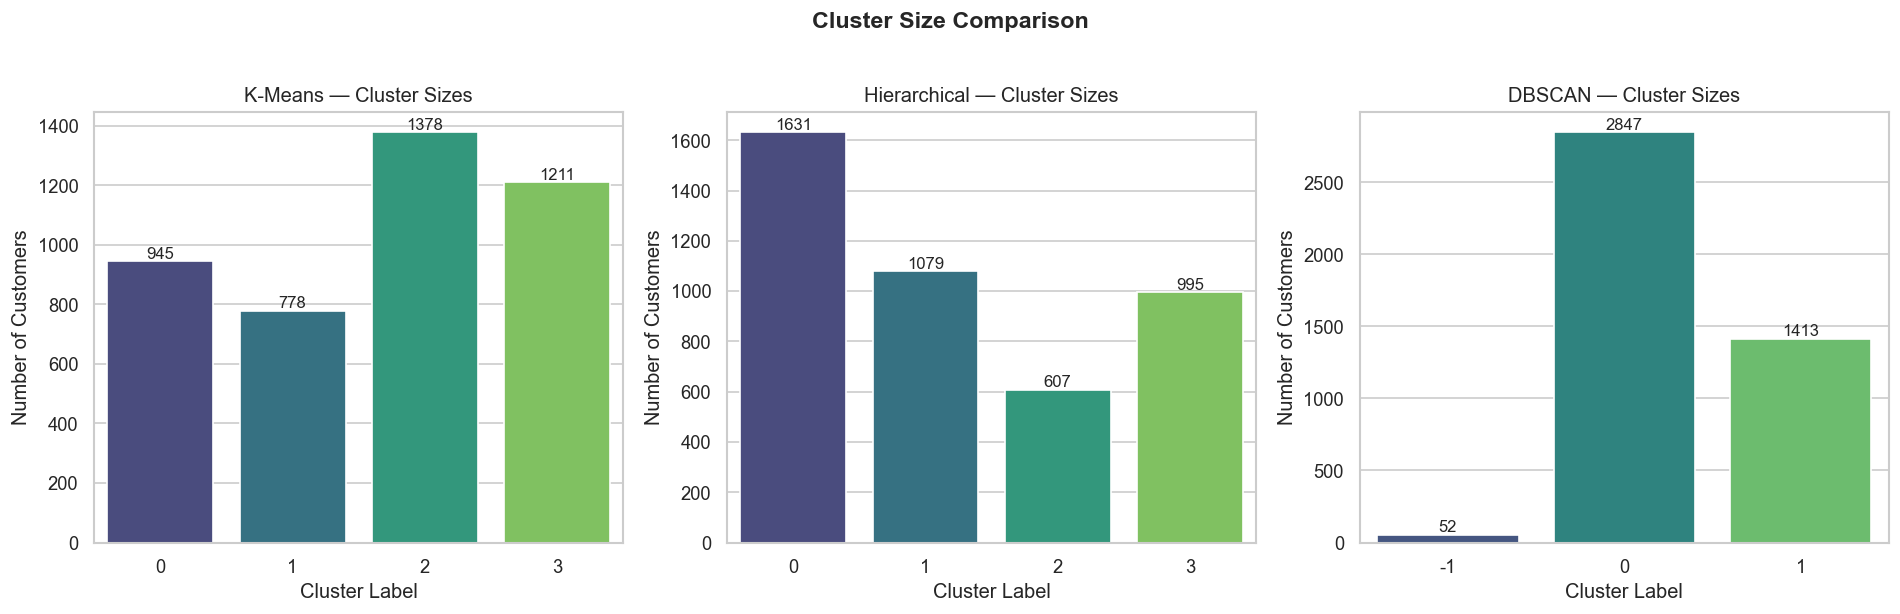

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, title in zip(axes, cluster_cols, titles):
    counts = rfm[col].value_counts().sort_index()
    sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="viridis")
    ax.set_title(f"{title} — Cluster Sizes")
    ax.set_xlabel("Cluster Label")
    ax.set_ylabel("Number of Customers")
    for p in ax.patches:
        ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha="center", va="bottom", fontsize=10)

plt.suptitle("Cluster Size Comparison", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

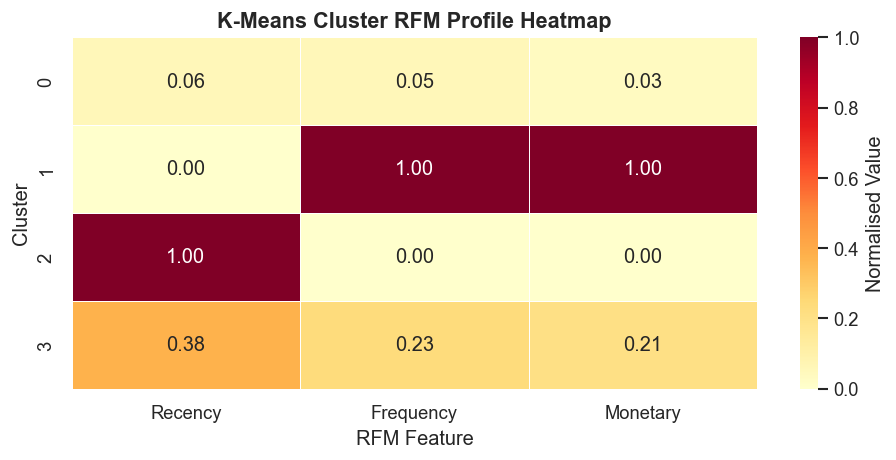

In [49]:
# Heatmap: K-Means cluster mean RFM (normalised for readability)
from sklearn.preprocessing import MinMaxScaler

kmeans_heatmap = rfm.groupby("KMeans_Cluster")[["Recency", "Frequency", "Monetary"]].mean()

mms = MinMaxScaler()
kmeans_heatmap_norm = pd.DataFrame(
    mms.fit_transform(kmeans_heatmap),
    index=kmeans_heatmap.index,
    columns=kmeans_heatmap.columns
)

plt.figure(figsize=(8, 4))
sns.heatmap(
    kmeans_heatmap_norm,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Normalised Value"}
)
plt.title("K-Means Cluster RFM Profile Heatmap", fontsize=13, fontweight="bold")
plt.xlabel("RFM Feature")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

In [51]:
# Export the final RFM + cluster labels dataframe
rfm.to_csv("rfm_clusters.csv", index=False)

print("Saved → rfm_clusters.csv")
print(rfm[["Customer ID", "Recency", "Frequency", "Monetary",
           "KMeans_Cluster", "Hierarchical_Cluster", "DBSCAN_Cluster"]].head(10))

Saved → rfm_clusters.csv
   Customer ID  Recency  Frequency  Monetary  KMeans_Cluster  \
0      12346.0      165         11    372.86               3   
1      12347.0        3          2   1323.32               0   
2      12348.0       74          1    222.16               2   
3      12349.0       43          3   2671.14               3   
4      12351.0       11          1    300.93               0   
5      12352.0       11          2    343.80               0   
6      12353.0       44          1    317.76               0   
7      12355.0      203          1    488.21               2   
8      12356.0       16          3   3560.30               3   
9      12357.0       24          2  12079.99               3   

   Hierarchical_Cluster  DBSCAN_Cluster  
0                     0              -1  
1                     0               0  
2                     3               1  
3                     0               0  
4                     3               1  
5                 

---
## ✅ Conclusion

| Algorithm | Strength | Weakness |
|---|---|---|
| **K-Means** | Fast, interpretable clusters | Sensitive to outliers, requires K |
| **Hierarchical** | No K needed at fit time; dendrogram shows hierarchy | Slow on large datasets |
| **DBSCAN** | Finds arbitrary shapes, flags outliers | Sensitive to `eps` and `min_samples` |

**Recommended cluster labels** for business use: **K-Means** (highest silhouette + fastest).  
Use the RFM profile heatmap to label clusters as:  
- 🥇 **Champions** — Low Recency, High Frequency, High Monetary  
- 💤 **At Risk** — High Recency, Low Frequency  
- 🆕 **New Customers** — Low Recency, Low Frequency  
- 💎 **Loyal** — Medium Recency, High Frequency, Medium Monetary